# Bayesian Fama-MacBeth

The methodology implemented here follows the [original study](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4989615) from Bryzgalova, Huang & Julliard. The classical Fama-MacBeth procedure delivers point estimates of risk premia $\lambda$ together with Shanken-corrected standard errors. The Bayesian Fama-MacBeth (BFM) replaces those point estimates with a full posterior distribution over $\lambda$, which side-steps the errors-in-variables problem in the second stage and makes uncertainty quantification immediate — credible intervals come directly from the posterior draws, with no asymptotic approximation.

In [1]:
from empfin import BFM, BFMOMIT, ff25p, ff5f

## Data

We illustrate the estimator on the canonical Fama-French dataset: the **25 portfolios** double-sorted on size and book-to-market as test assets, and the **5 Fama-French factors** (Mkt-RF, SMB, HML, RMW, CMA) as the candidate priced factors. The two convenience loaders `ff25p` and `ff5f` return aligned monthly DataFrames; `ff5f` also returns the risk-free rate as a second element, which we discard here since the portfolios are already excess returns.

In [2]:
ports = ff25p()
facts, _ = ff5f()

## Running the estimator

The `BFM` class takes three arguments:

- `assets` — DataFrame of test-asset (excess) returns, one column per asset.
- `factors` — DataFrame of factor returns. Indexes are aligned and any rows with missing values are dropped internally.
- `n_draws` — number of independent draws from the posterior. The whole sampler is closed-form (no MCMC), so each draw is cheap and you can ask for tens of thousands without much pain. We use `10_000` here for smooth posterior histograms.

All the work happens inside the constructor. Once it returns, the instance holds the posterior draws as `draws_mu_y`, `draws_Sigma_y`, `draws_betas`, `draws_lambdas`, and `draws_r2` — every downstream method (`ci_table_lambda`, `plot_lambda`, …) just summarizes those arrays.

In [3]:
bfm = BFM(
    assets=ports,
    factors=facts,
    n_draws=10_000,
)

## Posterior credible intervals

`ci_table_lambda(cred=c)` returns three quantiles of the posterior for each factor's risk premium: the lower tail at $(1-c)/2$, the posterior median, and the upper tail at $(1+c)/2$. The middle row is the natural Bayesian point estimate, andthe outer and upper rows define the **credible interval**.

In [4]:
print(bfm.ci_table_lambda(cred=0.90))

             Mkt-RF       SMB       HML       RMW       CMA
Quantiles                                                  
0.05       0.248859  0.082668  0.082851  0.130948 -0.187787
0.50       0.523369  0.276959  0.273864  0.428812  0.137434
0.95       0.792775  0.466033  0.461719  0.721342  0.458854


The `plot_lambda` method plots the posterior distribution of the risk premia estimates, and has the option of adding the traditional Fama-MacBeth regressions to the plot, for comparison.

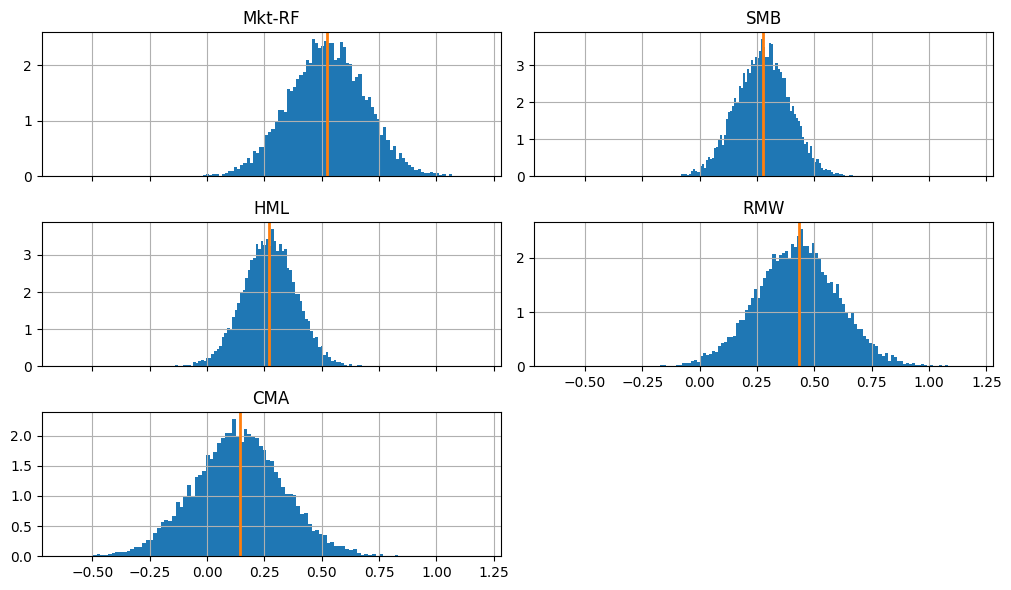

In [5]:
bfm.plot_lambda(include_fm=True)

# Accounting for omitted factors with BFM-OMIT

Both `BFM` and `BFMGLS` assume that the observable factors $f_t$ span the stochastic discount factor — every priced source of risk is captured by the factors we hand in. This is usually too optimistic in practice: there can be latent, unobserved priced factors, and ignoring them biases the risk premia of the observable ones.

`BFMOMIT` addresses this following the Giglio-Xiu (2021) idea, adapted to the Bayesian framework. For each posterior draw of the asset-return covariance $\Sigma_{R,(j)} = U_{(j)}\Lambda_{(j)} U_{(j)}^\top$, the latent factor loadings are taken as

$$
\beta_{v,(j)} = \big(\text{first $P$ columns of}\ U_{(j)}\Lambda_{(j)}^{1/2}\big),
$$

so the latent factors are the leading $P$ principal components of returns. The risk premia of these latent factors come from a plain OLS cross-sectional regression, and the observable factor's premium is recovered by projecting the observable factor onto the priced latent space:

$$
\lambda_{f,(j)} \;=\; \boldsymbol{\Sigma}_{Rf,(j)}^{\top}\, \boldsymbol{U}_{P,(j)}\, \boldsymbol{\Lambda}_{P,(j)}^{-1}\, \boldsymbol{U}_{P,(j)}^{\top}\, \boldsymbol{\mu}_{R,(j)}.
$$

Intuitively, an observable factor earns a risk premium only to the extent that it correlates with the priced latent factors — the unspanned component of $f$ gets no compensation. The extra constructor argument `p` is the number of latent components $P$ to keep; too few under-fits (real priced factors are still omitted), too many absorbs noise. We use $P = 5$ here, matching the number of Fama-French factors in the cross-section.

In [6]:
bfm_omit = BFMOMIT(
    assets=ports,
    factors=facts,
    n_draws=10_000,
    p=5,
)

## Posterior credible intervals

The same `ci_table_lambda` summary now reports the risk premia of the observable Fama-French factors *after* correcting for omitted latent risk. As discussed in the paper's empirical examples, BFM-OMIT estimates are typically closer to zero than BFM-OLS ones — part of what the unconstrained Bayesian Fama-MacBeth attributed to each observable factor is reattributed to the latent SDF components. Factors whose 90% interval still excludes zero are the ones that load on a priced latent source of risk.

In [7]:
print(bfm_omit.ci_table_lambda(cred=0.90))

             Mkt-RF       SMB       HML       RMW       CMA
Quantiles                                                  
0.05       0.252016  0.057825  0.125631 -0.043909  0.012724
0.50       0.529054  0.240181  0.308219  0.036101  0.107383
0.95       0.798798  0.424430  0.486044  0.118337  0.204975


The histogram below shows the BFM-OMIT posterior for each factor's risk premium, with a vertical line at the canonical OLS Fama-MacBeth point estimate. Mass that previously sat away from zero in the plain BFM plot typically recenters closer to zero here — the visual fingerprint of the omitted-factor correction.

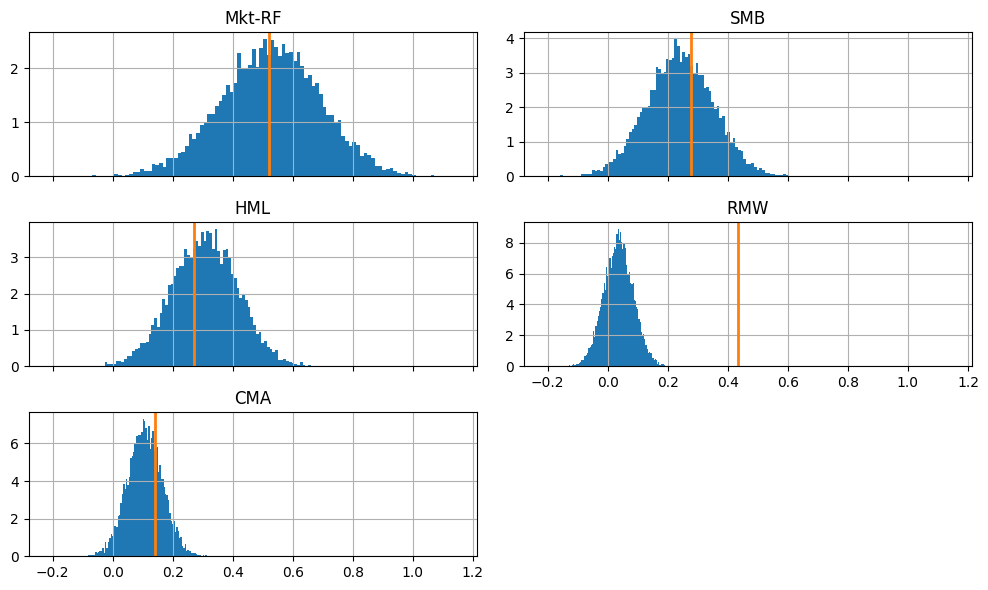

In [8]:
bfm_omit.plot_lambda(include_fm=True)